In [ ]:
!pip install gymnasium numpy matplotlib ipykernel tqdm ipywidgets jupyter imageio[ffmpeg]
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install "gymnasium[classic-control]"
!pip install "stable-baselines3[extra]"


In [2]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm
from IPython.display import Video, clear_output
import imageio
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold, BaseCallback
from stable_baselines3.common.monitor import Monitor
import pickle
from collections import deque

plt.style.use('paper.mplstyle')


In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


### Define custom environment with refined reward function

In [ ]:
class MountainCarEnergyWrapper1(gym.Wrapper):
    def __init__(self, env):
        # This properly initializes the base gym wrapper structure
        super().__init__(env)
        
    def step(self, action):
        # Execute the action in the real environment first
        obs, reward, done, trunc, info = self.env.step(action)
        
        position, velocity = obs[0], obs[1]

        position_reward = 0.1 * (position + 0.5) ** 2

        shaped_reward = position_reward
        shaped_reward -= 0.03 * (action[0] ** 2)
        shaped_reward -= 0.0005 # Step penalty to encourage faster solutions
        
        
        if position >= 0.45:
            shaped_reward += 100.0
            
        return obs, shaped_reward, done, trunc, info

    def reset(self, **kwargs):
        # Ensure reset passes down any seeds or options properly
        return self.env.reset(**kwargs)


class MountainCarEnergyWrapper2(gym.Wrapper):
    def __init__(self, env):
        # This properly initializes the base gym wrapper structure
        super().__init__(env)
        
    def step(self, action):
        # Execute the action in the real environment first
        obs, reward, done, trunc, info = self.env.step(action)
        
        position, velocity = obs[0], obs[1]

        if position > -0.5:
            position_reward = 1.0 * (position + 0.5) ** 2
        else:
            position_reward = 0.5 * (position + 0.5) ** 2
        
        if velocity > 0:
            velocity_reward = 100 * (velocity ** 2)
        else:
            velocity_reward = 50 * (velocity ** 2)
        shaped_reward = position_reward + velocity_reward

        shaped_reward -= 1.0
        
        if position >= 0.45:
            shaped_reward += 100.0
            
        return obs, shaped_reward, done, trunc, info

    def reset(self, **kwargs):
        # Ensure reset passes down any seeds or options properly
        return self.env.reset(**kwargs)


class MountainCarEnergyWrapperRef(gym.Wrapper):
    def __init__(self, env):
        # This properly initializes the base gym wrapper structure
        super().__init__(env)
        
    def step(self, action):
        # Execute the action in the real environment first
        obs, reward, done, trunc, info = self.env.step(action)
        
        position, velocity = obs[0], obs[1]

        position_reward = 5.0 * (position + 0.5) ** 2
        
        shaped_reward = position_reward

        shaped_reward -= 1.0
        
        if position >= 0.45:
            shaped_reward += 100.0
            
        return obs, shaped_reward, done, trunc, info

    def reset(self, **kwargs):
        # Ensure reset passes down any seeds or options properly
        return self.env.reset(**kwargs)


In [4]:
def evaluate_sb3_policy(model, env_name="MountainCarContinuous-v0", episodes=50, render=False):
    env = gym.make(env_name, render_mode="human" if render else None)

    rewards = []

    pbar = tqdm(range(episodes), desc="Evaluating SB3 Policy")

    for _ in pbar:
        obs, _ = env.reset()

        done = False
        total_reward = 0

        while not done:
            action, _states = model.predict(obs, deterministic=True)

            obs, reward, done, trunc, _ = env.step(action)
            total_reward += reward

            if trunc:
                break

        rewards.append(total_reward)

        pbar.set_postfix(avg_reward=np.mean(rewards))

    env.close()

    return np.mean(rewards), np.std(rewards), rewards


#### Train $\pi_1$

In [ ]:
set_seed(1)

base_env = gym.make("MountainCarContinuous-v0")
env = MountainCarEnergyWrapper1(base_env)
env = Monitor(env)

reward_threshold = 95.0
stop_callback = StopTrainingOnRewardThreshold(
    reward_threshold=reward_threshold, 
    verbose=1
)
eval_callback = EvalCallback(
    base_env, 
    callback_on_new_best=stop_callback, 
    eval_freq=2000,
    n_eval_episodes=10,
    verbose=0
)

model = PPO(
    "MlpPolicy", 
    env, 
    learning_rate=5e-3,    # The standard learning rate you had in your original code
    n_steps=1024,          # Number of steps to run per optimization batch
    batch_size=64,         # Minibatch size for the gradient updates
    n_epochs=10,           # Number of times to optimize over the collected data batch
    gamma=0.99,            # Discount factor
    verbose=0
)

model.learn(total_timesteps=30000, progress_bar=True, callback=eval_callback)

model.save("ppo_mountaincar_continuous_pi1")


Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 97.69 ± 0.41
Episode Rewards: [97.9917476876239, 97.92479935125051, 97.71320997880132, 98.00183540317256, 98.01740221223132, 97.70828728048777, 97.96934180664636, 97.53945991177136, 97.59631617603088, 97.99593819535062, 96.81048110236175, 97.68831073730401, 97.20664879443855, 97.36705012842631, 97.40675538552202, 97.12202117766613, 97.77777514751257, 97.05279386365484, 96.66399240115487, 97.87379921412949, 97.89311678168681, 96.9088741004452, 98.39536481420234, 98.39326747605506, 97.52894930375832, 97.3835084098077, 97.52480516634438, 97.39463474054534, 97.40793892793776, 97.78717510626988, 97.97560159403952, 97.13430173617249, 97.68581314670773, 98.18695653203308, 97.33773406539451, 98.04589073830901, 98.17572516497212, 97.38317100413359, 97.63545599889201, 97.64487822069313, 97.356319584487, 98.19971258702425, 97.838406435309, 97.61993974206347, 97.64431412434409, 98.35706399218026, 97.78581868310881, 98.18466142065614, 98.15877416032882, 98.185440098

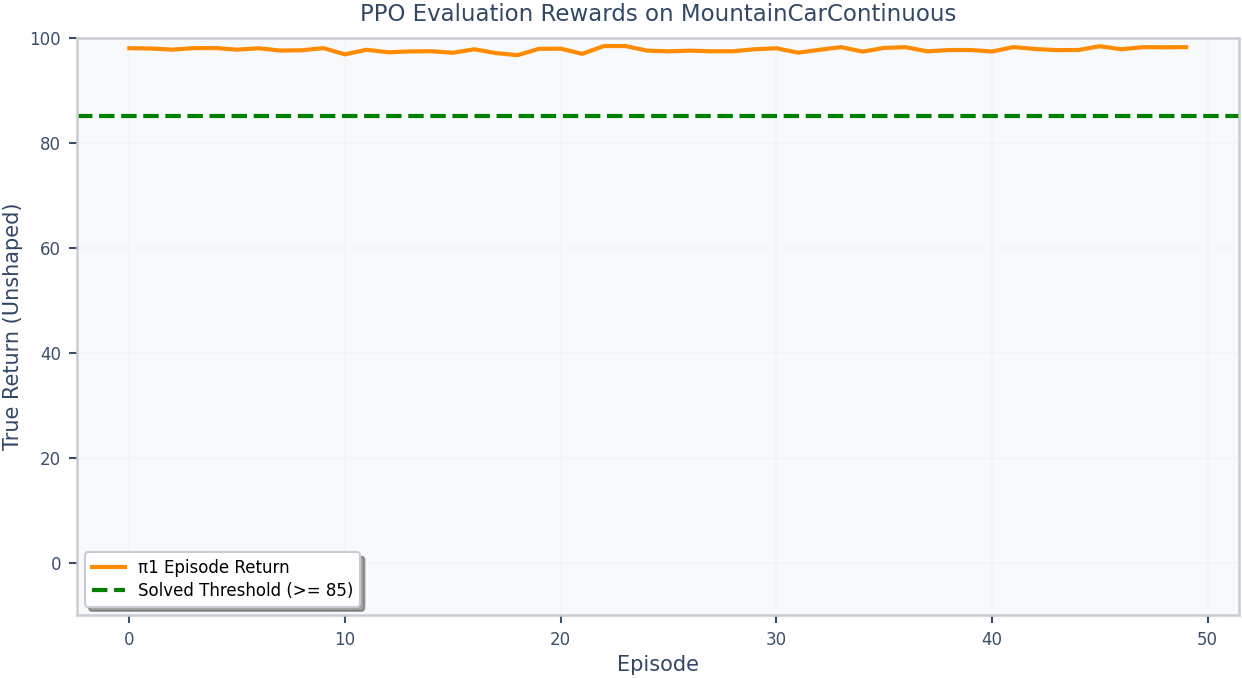

In [ ]:
pi1 = PPO.load("ppo_mountaincar_continuous_pi1.zip")

mean_reward1, std_reward1, episode_rewards1 = evaluate_sb3_policy(pi1, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward1:.2f} ± {std_reward1:.2f}")
print(f"Episode Rewards: {episode_rewards1}")


plt.figure(figsize=(10, 5))
plt.plot(episode_rewards1, label="π1 Episode Return", color="darkorange", linewidth=2)
plt.axhline(y=85.0, color="green", linestyle="--", label="Solved Threshold (>= 85)")
plt.title("PPO Evaluation Rewards on MountainCarContinuous")
plt.xlabel("Episode")
plt.ylabel("True Return (Unshaped)")
plt.ylim(-10, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Train $\pi_2$

In [ ]:
set_seed(2)

base_env = gym.make("MountainCarContinuous-v0")
env = MountainCarEnergyWrapper2(base_env)
env = Monitor(env)

class RewardWindowCallback(BaseCallback):
    def __init__(self, min_reward=50.0, max_reward=90.0, verbose=0):
        super().__init__(verbose)
        self.min_reward = min_reward
        self.max_reward = max_reward

    def _on_step(self) -> bool:
        if "episode" in self.locals["infos"][0]:
            episode_reward = self.locals["infos"][0]["episode"]["r"]
            
            if self.min_reward <= episode_reward <= self.max_reward:
                print(f"\n[TARGET HIT] Episode reward was {episode_reward:.2f} (Between {self.min_reward} and {self.max_reward})!")
                print("Stopping training early...")
                return False
                
        return True

reward_threshold = 45
stop_callback = StopTrainingOnRewardThreshold(
    reward_threshold=reward_threshold, 
    verbose=1
)
eval_callback = EvalCallback(
    base_env, 
    callback_on_new_best=stop_callback, 
    eval_freq=2000,
    n_eval_episodes=3,
    verbose=0
)


model = PPO(
    "MlpPolicy", 
    env, 
    learning_rate=1e-3,    # The standard learning rate you had in your original code
    n_steps=1024,          # Number of steps to run per optimization batch
    batch_size=64,         # Minibatch size for the gradient updates
    n_epochs=10,           # Number of times to optimize over the collected data batch
    gamma=0.99,            # Discount factor
    verbose=0
)

model.learn(total_timesteps=30000, progress_bar=True, callback=eval_callback)

model.save("ppo_mountaincar_continuous_pi2")


Output()

/home/till/epfl/26s/rl/project/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: 
UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

Stopping training because the mean reward 65.72 is above the threshold 45

Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 2.51 ± 53.63
Episode Rewards: [-43.55798013497121, 69.07189851961704, -39.8563984521161, 69.07025307936584, -40.64974689638638, -43.882000128533655, 75.18239998566116, 59.20235424437942, -40.04388008685633, -40.01480586502, 62.46609249891158, 69.07219029785468, -39.96847306546217, 58.91740094836557, -40.445174820485725, -39.8359611651302, 72.41148201243657, -39.860011325183564, -42.17477959422745, 65.24978895866286, 72.41271579744402, 61.9165804107026, -43.892802883710004, 61.24050045066936, -40.218221105583375, -41.58091547526063, -39.97205853439751, -43.933372657253486, -40.67910473984102, -40.004835415445235, -40.152797821479496, -40.168676755304226, -43.94045908938013, -43.94323492399616, -39.80988038607078, -40.039079262891, -40.07438245464156, -40.19942786223109, -39.947159124484365, 75.74347381677184, 75.83992308837415, -41.6415664643469, 72.12693520972599, 69.01755454260035, -43.882567650062036, 68.97733839427593, 61.543003934526894, 72.41506295

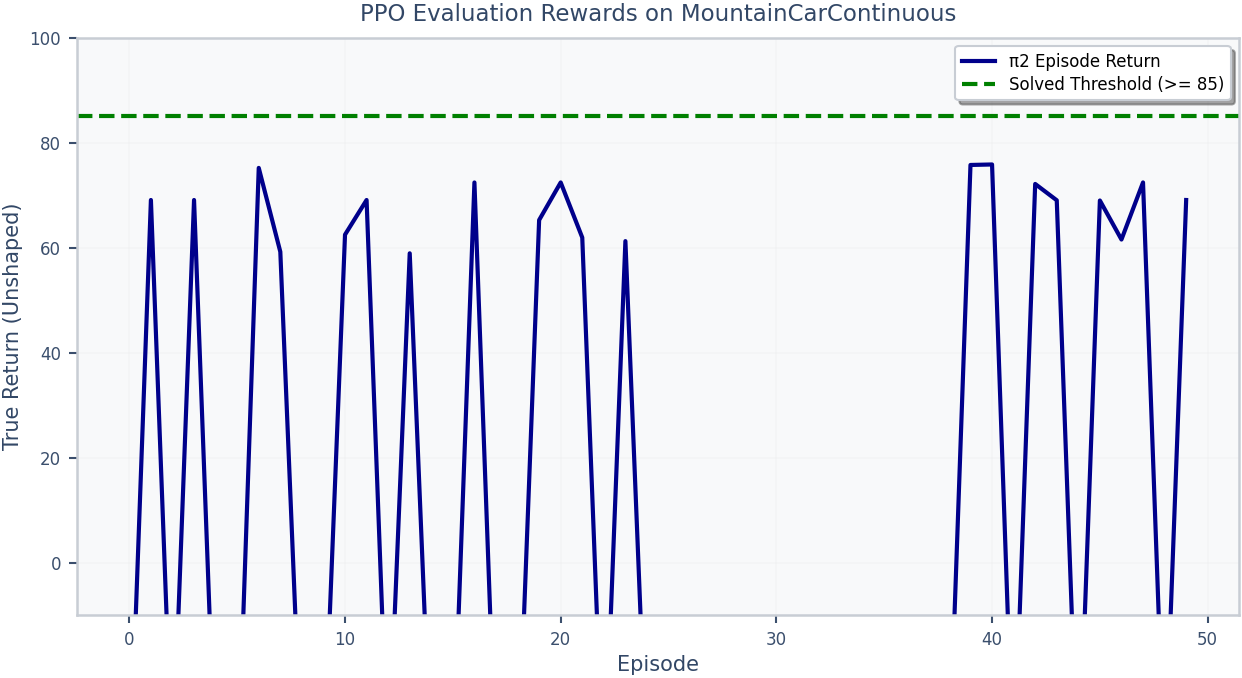

In [ ]:
pi2 = PPO.load("ppo_mountaincar_continuous_pi2.zip")

mean_reward2, std_reward2, episode_rewards2 = evaluate_sb3_policy(pi2, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward2:.2f} ± {std_reward2:.2f}")
print(f"Episode Rewards: {episode_rewards2}")


plt.figure(figsize=(10, 5))
plt.plot(episode_rewards2, label="π2 Episode Return", color="darkblue", linewidth=2)
plt.axhline(y=85.0, color="green", linestyle="--", label="Solved Threshold (>= 85)")
plt.title("PPO Evaluation Rewards on MountainCarContinuous")
plt.xlabel("Episode")
plt.ylabel("True Return (Unshaped)")
plt.ylim(-10, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Train $\pi_{ref}$

In [ ]:
set_seed(1)

base_env = gym.make("MountainCarContinuous-v0")
env = MountainCarEnergyWrapperRef(base_env)
env = Monitor(env)

reward_threshold = 55.0
stop_callback = StopTrainingOnRewardThreshold(
    reward_threshold=reward_threshold, 
    verbose=1
)
eval_callback = EvalCallback(
    base_env, 
    callback_on_new_best=stop_callback, 
    eval_freq=2000,
    n_eval_episodes=5,
    verbose=0
)

model = PPO(
    "MlpPolicy", 
    env, 
    learning_rate=5e-3,    # The standard learning rate you had in your original code
    n_steps=1024,          # Number of steps to run per optimization batch
    batch_size=64,         # Minibatch size for the gradient updates
    n_epochs=10,           # Number of times to optimize over the collected data batch
    gamma=0.99,            # Discount factor
    verbose=0
)

model.learn(total_timesteps=20000, progress_bar=True)

model.save("ppo_mountaincar_continuous_pi_ref")


Output()

Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 89.03 ± 2.36
Episode Rewards: [89.23620762954823, 90.6645153956169, 91.07637089268235, 90.44844249483337, 91.17912046213804, 89.80689153881221, 85.56655697884132, 85.14442739226962, 91.1552092078172, 90.86568443922772, 88.9680414630922, 85.81713664274777, 90.9666182716812, 90.97407924554815, 84.95137921117218, 85.80826455847401, 85.63063007194685, 90.49506542436332, 91.15734280071078, 90.9664618004674, 90.06602566863127, 91.08383303628874, 91.1871987522175, 89.04826392226002, 90.46272447068206, 90.0500951793142, 91.10019760701807, 88.39087355291441, 89.8035873283518, 88.22210494187615, 85.21464673243554, 85.8129894186495, 85.66525394391839, 90.93039005432075, 85.15455634354291, 85.03423101564397, 91.12026326359258, 90.96809914033462, 91.16237613427081, 90.89129184730106, 90.66802695475897, 91.13311618435324, 91.1482450254762, 85.60446185332033, 91.01473735955351, 88.77171566179742, 85.18983861037482, 89.05577522415523, 90.943773130989, 85.76882967892251

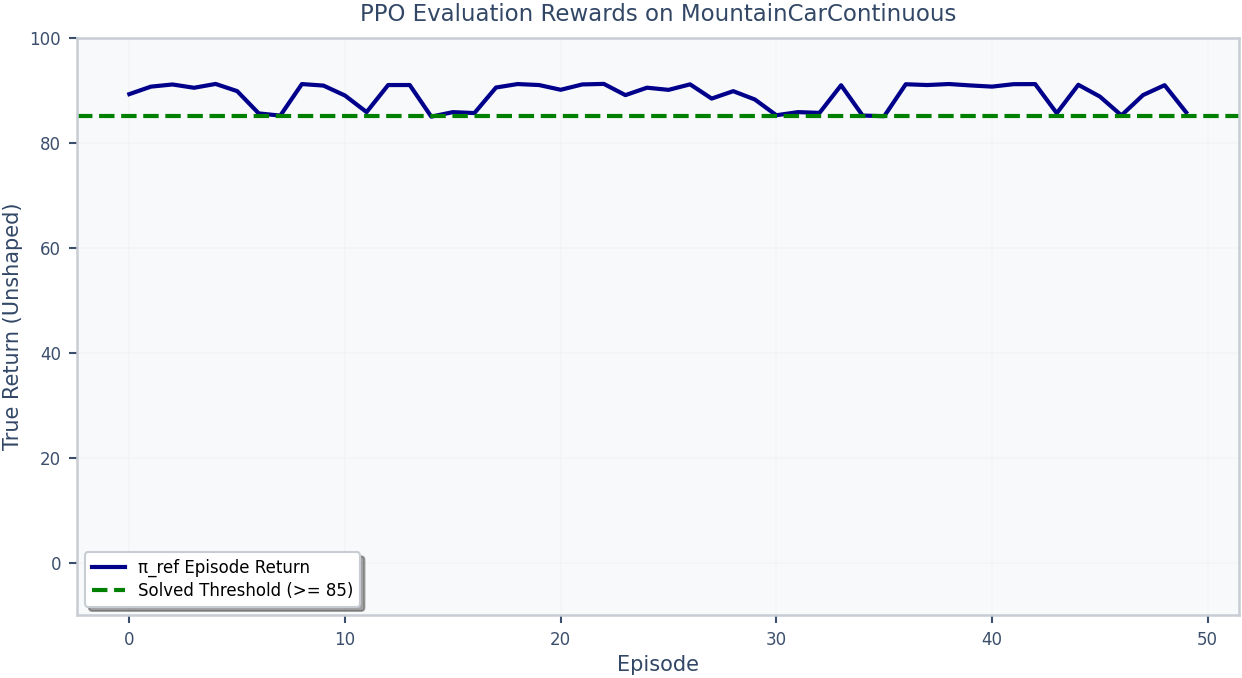

In [ ]:
pi_ref = PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip")

mean_reward_ref, std_reward_ref, episode_rewards_ref = evaluate_sb3_policy(pi_ref, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward_ref:.2f} ± {std_reward_ref:.2f}")
print(f"Episode Rewards: {episode_rewards_ref}")


plt.figure(figsize=(10, 5))
plt.plot(episode_rewards_ref, label="π_ref Episode Return", color="darkblue", linewidth=2)
plt.axhline(y=85.0, color="green", linestyle="--", label="Solved Threshold (>= 85)")
plt.title("PPO Evaluation Rewards on MountainCarContinuous")
plt.xlabel("Episode")
plt.ylabel("True Return (Unshaped)")
plt.ylim(-10, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Evaluate the trained policies

In [11]:
pi1 = PPO.load("ppo_mountaincar_continuous_pi1_save.zip")
pi2 = PPO.load("ppo_mountaincar_continuous_pi2_save.zip")
pi_ref = PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip")


mean_reward1, std_reward1, episode_rewards1 = evaluate_sb3_policy(pi1, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward1:.2f} ± {std_reward1:.2f}")
print(f"Episode Rewards: {episode_rewards1}")

mean_reward2, std_reward2, episode_rewards2 = evaluate_sb3_policy(pi2, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward2:.2f} ± {std_reward2:.2f}")
print(f"Episode Rewards: {episode_rewards2}")

mean_reward_ref, std_reward_ref, episode_rewards_ref = evaluate_sb3_policy(pi_ref, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward_ref:.2f} ± {std_reward_ref:.2f}")
print(f"Episode Rewards: {episode_rewards_ref}")


Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 98.91 ± 0.13
Episode Rewards: [98.88059069586932, 98.99548365457555, 99.09470829766738, 98.85828205189843, 99.13259881506602, 98.87573242196856, 98.8481466125528, 98.82076711957242, 98.9207042887686, 98.83472574574206, 99.08433301580595, 98.98389397507621, 98.90726089987832, 98.73478179402461, 98.97693280604993, 98.9236930092889, 98.65743647549154, 99.07938528069614, 99.07831631746122, 99.04714228197122, 98.84264757219282, 99.04397956331877, 98.8554505997677, 98.86437736709154, 98.72317340719852, 99.11788722202077, 99.0249699586329, 98.9736721664423, 99.05176840031443, 98.73339322817037, 98.99638235966866, 98.7471414612819, 98.93683003945031, 98.78323681427044, 98.87124058808695, 98.88376004752729, 98.67277277839415, 98.86082195252003, 99.0125932913809, 98.7990674153528, 98.75297576009662, 99.04549316401322, 98.94629823322845, 98.7242811740517, 98.91952873030846, 98.77457026518138, 98.91217024506274, 98.8714006117958, 98.8028072394519, 99.11998931039822

Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 65.22 ± 27.62
Episode Rewards: [64.70736647914076, 63.92905049781094, 69.35801664410418, 76.87120603047157, 83.3442129795774, 74.37161344170111, 62.2138651611095, 76.9156793543043, -40.33351944567297, 65.44308507449631, -41.07320446352397, 73.60960806004572, 76.98254455866, 77.41494220050959, 80.08727406032676, 70.30237542952494, 77.01240893604017, 69.84013103361904, 70.81186400090863, 76.35842689205546, 70.34679606158679, 79.76839393147944, 70.23713736095551, 69.03216714453775, 75.54566492894396, 58.775417826745105, 82.08202840226258, 66.97286616120988, 62.393222407120554, 82.96258399495309, 65.77061413684095, 79.09776650137655, 58.91064270312091, 83.56061938895277, 70.01602018862675, 76.91493359843092, 70.40950639661997, 60.654228028850234, 76.4128722919666, 60.15192714117896, 76.98213315689287, -39.578068616572764, 71.74860849060707, 56.497466907341966, 76.35707197787265, 79.80559304958177, 68.3805817895944, 79.88061530682401, 82.37728840176572, 60.5

Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 88.69 ± 2.54
Episode Rewards: [89.13900086185386, 89.45945335421052, 85.49203719852434, 90.97188491282866, 90.93203020088123, 85.81170288215506, 89.82087715294013, 85.28784336913311, 90.83868600835443, 90.20469752481274, 90.47382165063786, 91.09917460058935, 90.05498070250987, 85.59750785418986, 90.787351661451, 85.68295446910564, 90.95173173864703, 91.18769175856022, 90.20194216691557, 85.30870004393685, 85.73608300287371, 90.47666394313234, 85.75081993394399, 91.10455545381309, 91.16023938936814, 90.85546290935855, 91.10164955192819, 85.76773103355411, 91.15290714335251, 85.5942381352758, 90.92982890294844, 85.55174736519186, 90.6626467293199, 90.90241956486994, 85.6942472079088, 85.29640324617903, 90.8094290471654, 85.80969862659798, 89.93119903602391, 84.93809463760792, 90.80552411496458, 91.0353431646375, 85.56435335986734, 85.74361397337235, 84.3447403919023, 90.49846419289007, 85.49654777160217, 90.97541957753067, 90.85218252175376, 90.6595903215

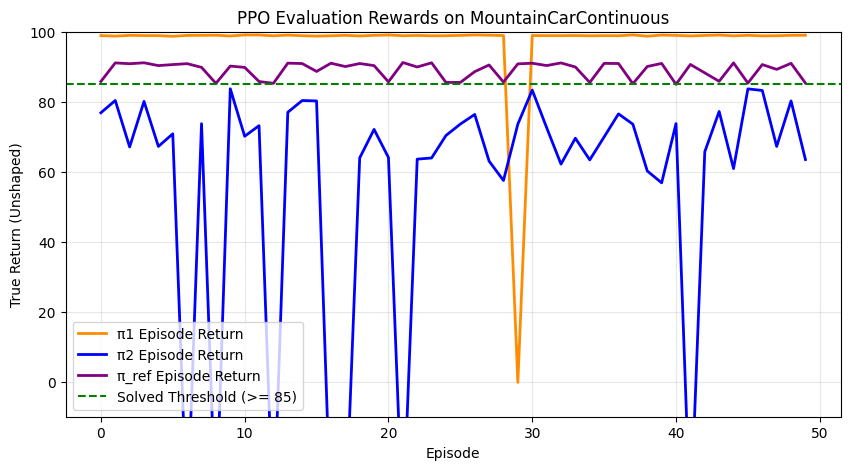

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(episode_rewards1, label="π1 Episode Return", color="darkorange", linewidth=2)
plt.plot(episode_rewards2, label="π2 Episode Return", color="blue", linewidth=2)
plt.plot(episode_rewards_ref, label="π_ref Episode Return", color="purple", linewidth=2)

plt.axhline(y=85.0, color="green", linestyle="--", label="Solved Threshold (>= 85)")
plt.title("PPO Evaluation Rewards on MountainCarContinuous")
plt.xlabel("Episode")
plt.ylabel("True Return (Unshaped)")
plt.ylim(-10, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Record result

In [48]:
def record_sb3_policy(model, env_name="MountainCarContinuous-v0", filename="mountain_car.mp4"):
    # Initialize the raw environment with rgb_array render mode to capture frames
    env = gym.make(env_name, render_mode="rgb_array")

    frames = []

    obs, _ = env.reset()
    done = False
    total_reward = 0
    while not done:
        frame = env.render()
        frames.append(frame)
        
        action, _states = model.predict(obs, deterministic=True)

        obs, reward, done, trunc, _ = env.step(action)
        total_reward += reward

        if trunc:
            break

    env.close()

    imageio.mimsave(filename, frames, fps=30)
    print(f"Video saved successfully to {filename}!")
    print(f"Total reward: {total_reward}")

    return filename


In [53]:
pi1 = PPO.load("ppo_mountaincar_continuous_pi1.zip")
video_file1 = record_sb3_policy(pi1, filename="mountain_car_ppo_pi1.mp4")
Video(video_file1)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved successfully to mountain_car_ppo_pi1.mp4!
Total reward: 98.13732753974944


In [ ]:
pi2 = PPO.load("ppo_mountaincar_continuous_pi2.zip")
video_file2 = record_sb3_policy(pi2, filename="mountain_car_ppo_pi2.mp4")
Video(video_file2)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved successfully to mountain_car_ppo_pi2.mp4!
Total reward: 68.32877569650573


In [ ]:
pi_ref = PPO.load("ppo_mountaincar_continuous_pi_ref.zip")
video_file_ref = record_sb3_policy(pi_ref, filename="mountain_car_ppo_pi_ref.mp4")
Video(video_file_ref)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved successfully to mountain_car_ppo_pi_ref.mp4!
Total reward: 85.6741224531522


---
## DPO
---

In [8]:
pi1 = PPO.load("ppo_mountaincar_continuous_pi1_save.zip")
pi2 = PPO.load("ppo_mountaincar_continuous_pi2_save.zip")
pi_ref = PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip")


In [ ]:
def rollout(env, policy, max_steps=999):
    obs, _ = env.reset()
    traj = []
    total_reward = 0

    for _ in range(max_steps):
        action, _ = policy.predict(obs, deterministic=True)

        next_obs, reward, done, trunc, _ = env.step(action)

        traj.append((obs, action, reward))
        total_reward += reward

        obs = next_obs
        if done or trunc:
            break

    return traj, total_reward


In [ ]:
def generate_preference_dataset(env, pi1, pi2, K=50):
    dataset = []
    dataset_rewards = []

    for _ in tqdm(range(K), desc="Generating preferences"):
        tau1, r1 = rollout(env, pi1)
        tau2, r2 = rollout(env, pi2)

        # preference probability with normalized rewards
        # r1 /= 100.0
        # r2 /= 100.0
        p = np.exp(r1) / (np.exp(r1) + np.exp(r2))

        if np.random.rand() < p:
            pref, rej = tau1, tau2
            r_pref, r_rej = r1, r2
        else:
            pref, rej = tau2, tau1
            r_pref, r_rej = r2, r1

        dataset.append((pref, rej))
        dataset_rewards.append((r_pref, r_rej))

    return dataset, dataset_rewards


In [ ]:
env = gym.make("MountainCarContinuous-v0")
pref_dataset, pref_rewards = generate_preference_dataset(env, pi1, pi2, K=200)


Generating preferences:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
with open("pref_dataset_200.pkl", "wb") as f:
    pickle.dump(pref_dataset, f)


In [ ]:
# tau = [(s0, a0, r0), (s1, a1, r1), ...]
wins = 0
for i, (pref, rej) in enumerate(pref_dataset):
    if pref_rewards[i][0] > pref_rewards[i][1]:
        wins += 1

print("Preferred trajectories higher reward fraction:", wins / len(pref_dataset))


Preferred trajectories higher reward fraction: 1.0


In [22]:
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
from tqdm import tqdm


def log_prob_traj(policy, traj, device):
    """
    Computes sum of log probs of actions in a trajectory.
    traj: list of (obs, act, reward)
    """
    obs = torch.as_tensor(
        np.asarray([t[0] for t in traj], dtype=np.float32),
        dtype=torch.float32,
        device=device,
    )

    act = torch.as_tensor(
        np.asarray([t[1] for t in traj], dtype=np.float32),
        dtype=torch.float32,
        device=device,
    )
    if act.ndim == 1:
        act = act.unsqueeze(-1)

    if not torch.isfinite(obs).all() or not torch.isfinite(act).all():
        raise ValueError("Non-finite observation or action found in trajectory")

    distribution = policy.get_distribution(obs)
    log_probs = distribution.log_prob(act)

    if not torch.isfinite(log_probs).all():
        raise ValueError("Non-finite log-probability encountered while evaluating trajectory")

    return log_probs.mean()


def dpo_loss(policy, ref_policy, pref_traj, rej_traj, beta, device):
    """
    Standard trajectory-level DPO loss.
    """
    pi_pref = log_prob_traj(policy, pref_traj, device)
    pi_rej = log_prob_traj(policy, rej_traj, device)

    with torch.no_grad():
        ref_pref = log_prob_traj(ref_policy, pref_traj, device)
        ref_rej = log_prob_traj(ref_policy, rej_traj, device)

    logits = beta * ((pi_pref - pi_rej) - (ref_pref - ref_rej))
    return -F.logsigmoid(logits)


def train_dpo(policy, ref_policy, pref_dataset, epochs=5, lr=1e-4, beta=0.05, device="cuda", batch_size=8, grad_clip=1.0):
    """
    pref_dataset: list of tuples: (preferred_traj, rejected_traj)
    """
    pref_dataset = pref_dataset.copy()  # Avoid modifying the original dataset
    policy.to(device)
    ref_policy.to(device)

    policy.train()
    ref_policy.eval()
    for p in ref_policy.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    losses = []
    rewards = []
    best_reward = -float('inf')
    best_policy = copy.deepcopy(policy)

    for epoch in tqdm(range(epochs), desc="DPO Training"):
        random.shuffle(pref_dataset)
        total_loss = 0.0
        minibatch_losses = []

        optimizer.zero_grad()

        for i, (pref, rej) in enumerate(pref_dataset):
            loss = dpo_loss(policy, ref_policy, pref, rej, beta, device)

            if not torch.isfinite(loss):
                raise ValueError("Non-finite DPO loss encountered")

            minibatch_losses.append(loss)
            total_loss += loss.item()

            last_item = (i + 1) == len(pref_dataset)
            if len(minibatch_losses) == batch_size or last_item:
                minibatch_loss = torch.stack(minibatch_losses).mean()
                minibatch_loss.backward()
                torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad()
                minibatch_losses.clear()

        epoch_reward = evaluate_sb3_policy(policy, episodes=6)[0]
        rewards.append(epoch_reward)
        epoch_loss = total_loss / len(pref_dataset)
        losses.append(epoch_loss)

        if epoch_reward > best_reward:
            best_reward = epoch_reward
            best_policy = copy.deepcopy(policy)
            print(f"New best DPO policy at epoch {epoch + 1}: reward={best_reward:.2f}")

        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        ax1 = plt.gca()
        ax1.plot(losses, color='red', marker='o', label='Loss')
        ax1.set_yscale('log')
        ax1.set_ylabel('Average Loss', color='red')
        ax1.tick_params(axis='y', labelcolor='red')
        
        ax2 = ax1.twinx()
        ax2.plot(rewards, color='blue', marker='s', label='Reward')
        ax2.set_ylabel('Reward', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')
        
        plt.title(f"DPO Training Progress | Epoch {epoch + 1}")
        ax1.set_xlabel('Epoch')
        plt.grid(True, alpha=0.3)
        plt.show()

        print(f"Epoch {epoch + 1} | Loss: {epoch_loss:.4f}")

    print(f"Returning best DPO policy with reward={best_reward:.2f}")
    return best_policy


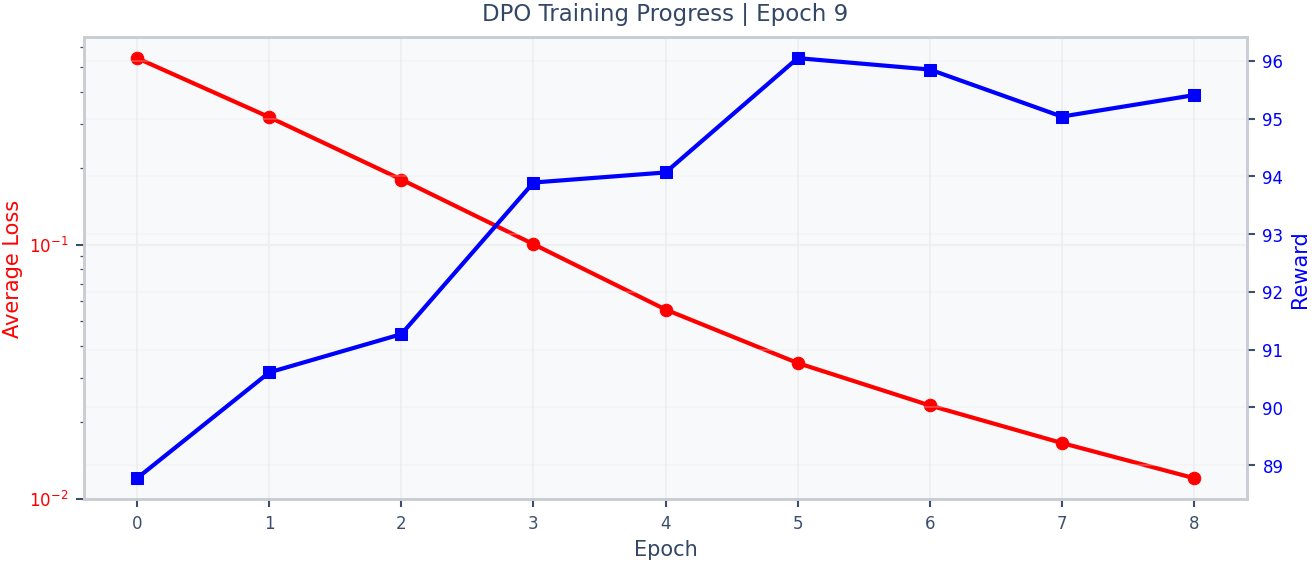

DPO Training: 100%|██████████| 9/9 [00:31<00:00,  3.45s/it]

Epoch 9 | Loss: 0.0121
Returning best DPO policy with reward=96.05


In [45]:
set_seed(2)
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
env = gym.make("MountainCarContinuous-v0")


with open("pref_dataset_500.pkl", "rb") as f:
    pref_dataset = pickle.load(f)

# DPO policy
dpo_model = copy.deepcopy(PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip"))
dpo_model.policy.to(device)
dpo_policy = dpo_model.policy

# Reference policy
ref_model = copy.deepcopy(PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip"))
ref_model.policy.to(device)
ref_policy = ref_model.policy
ref_policy.eval()  # Freeze reference policy
for p in ref_policy.parameters():
    p.requires_grad = False


# TRAIN
trained_policy = train_dpo(
    policy=dpo_policy,
    ref_policy=ref_policy,
    pref_dataset=pref_dataset,
    epochs=9,
    lr=6e-6,
    beta=5,
    device=device,
    batch_size=1,
    grad_clip=1.0,
)

dpo_model.policy = trained_policy
dpo_model.save("dpo_mountaincar_continuous.zip")


In [ ]:
dpo_model.save("models/dpo_goat.zip")

/home/till/epfl/26s/rl/project/.venv/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'models' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


Evaluating SB3 Policy: 100%|██████████| 50/50 [00:02<00:00, 16.78it/s, avg_reward=95.4]


Average Reward over 50 episodes: 95.40 ± 0.90


Evaluating SB3 Policy: 100%|██████████| 50/50 [00:05<00:00,  9.29it/s, avg_reward=98.9]


Average Reward over 50 episodes: 98.90 ± 0.14


Evaluating SB3 Policy: 100%|██████████| 50/50 [00:02<00:00, 23.74it/s, avg_reward=88.3]


Average Reward over 50 episodes: 88.26 ± 2.55


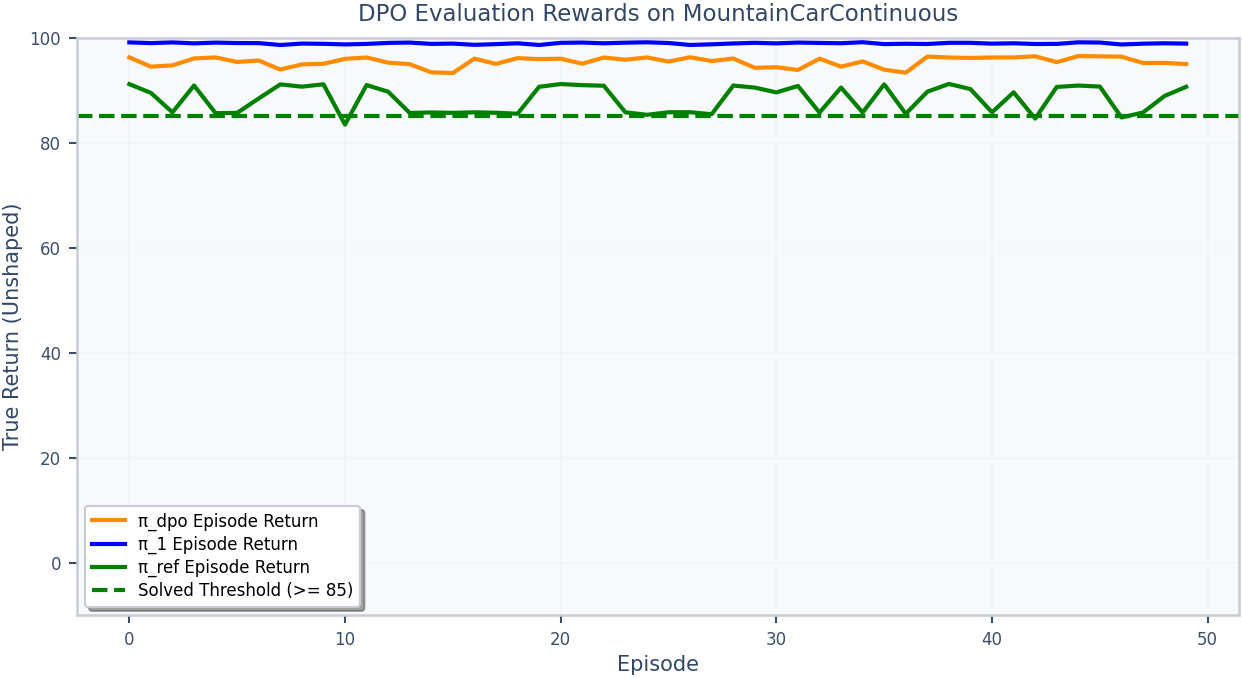

In [46]:
pi_dpo= PPO.load("dpo_mountaincar_continuous.zip")
pi1 = PPO.load("ppo_mountaincar_continuous_pi1_save.zip")
pi_ref = PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip")


mean_reward_dpo, std_reward_dpo, episode_rewards_dpo = evaluate_sb3_policy(pi_dpo, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward_dpo:.2f} ± {std_reward_dpo:.2f}")

mean_reward1, std_reward1, episode_rewards1 = evaluate_sb3_policy(pi1, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward1:.2f} ± {std_reward1:.2f}")

mean_reward_ref, std_reward_ref, episode_rewards_ref = evaluate_sb3_policy(pi_ref, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward_ref:.2f} ± {std_reward_ref:.2f}")


# 3. Plot the performance results
plt.figure(figsize=(10, 5))

plt.plot(episode_rewards_dpo, label="π_dpo Episode Return", color="darkorange", linewidth=2)
plt.plot(episode_rewards1, label="π_1 Episode Return", color="blue", linewidth=2)
plt.plot(episode_rewards_ref, label="π_ref Episode Return", color="green", linewidth=2)

plt.axhline(y=85.0, color="green", linestyle="--", label="Solved Threshold (>= 85)")
plt.title("DPO Evaluation Rewards on MountainCarContinuous")
plt.xlabel("Episode")
plt.ylabel("True Return (Unshaped)")
plt.ylim(-10, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [49]:
pi = PPO.load("dpo_mountaincar_continuous.zip")
video_file = record_sb3_policy(pi, filename="mountain_car_dpo.mp4")
Video(video_file)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved successfully to mountain_car_dpo.mp4!
Total reward: 95.90868474077105


### DPO Parameter sweep

In [11]:
import copy
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "MountainCarContinuous-v0"
base_model_path = "ppo_mountaincar_continuous_pi_ref_save.zip"
results_path = "dpo_parameter_sweep_results_K2000.pkl"
best_models_dir = Path("dpo_parameter_sweep_best_models")
best_models_dir.mkdir(exist_ok=True)

def beta_to_tag(beta):
    return str(beta).replace("-", "m").replace("+", "p").replace(".", "p")

def train_dpo_with_history(
    policy,
    ref_policy,
    pref_dataset,
    epochs=5,
    lr=1e-4,
    beta=0.05,
    device="cuda",
    batch_size=8,
    grad_clip=1.0,
    eval_episodes=6,
):
    pref_dataset = pref_dataset.copy()
    policy.to(device)
    ref_policy.to(device)

    policy.train()
    ref_policy.eval()
    for param in ref_policy.parameters():
        param.requires_grad = False

    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    losses = []
    rewards = []
    best_reward = -float("inf")
    best_epoch = -1
    best_policy = copy.deepcopy(policy)

    for epoch in tqdm(range(epochs), desc=f"DPO sweep | K={len(pref_dataset)} | beta={beta:g}"):
        random.shuffle(pref_dataset)
        total_loss = 0.0
        minibatch_losses = []

        optimizer.zero_grad()

        for i, (pref, rej) in enumerate(pref_dataset):
            loss = dpo_loss(policy, ref_policy, pref, rej, beta, device)

            if not torch.isfinite(loss):
                raise ValueError("Non-finite DPO loss encountered during sweep")

            minibatch_losses.append(loss)
            total_loss += loss.item()

            last_item = (i + 1) == len(pref_dataset)
            if len(minibatch_losses) == batch_size or last_item:
                minibatch_loss = torch.stack(minibatch_losses).mean()
                minibatch_loss.backward()
                torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad()
                minibatch_losses.clear()

        epoch_reward = evaluate_sb3_policy(policy, env_name=env_name, episodes=eval_episodes)[0]
        epoch_loss = total_loss / len(pref_dataset)
        losses.append(epoch_loss)
        rewards.append(epoch_reward)

        if epoch_reward > best_reward:
            best_reward = epoch_reward
            best_epoch = epoch + 1
            best_policy = copy.deepcopy(policy)

    history = {
        "losses": losses,
        "rewards": rewards,
        "best_reward": best_reward,
        "best_epoch": best_epoch,
    }

    return best_policy, history
# 50->7e-5, 200->2e-5, 500->6e-6, 2000->2e-6
def run_dpo_parameter_sweep(
    dataset_sizes=[2000],
    betas=(0.0, 5e-3, 5e-2, 5e-1, 5.0, 50.0),
    epochs=9,
    lr=2e-6,
    batch_size=1,
    grad_clip=1.0,
    eval_episodes=6,
    seeds=(0, 1, 2),
    save_path=results_path,
):
    base_model = PPO.load(base_model_path)
    sweep_results = []

    for dataset_size in dataset_sizes:
        dataset_path = Path(f"pref_dataset_{dataset_size}.pkl")
        if not dataset_path.exists():
            raise FileNotFoundError(f"Missing preference dataset: {dataset_path}")

        with dataset_path.open("rb") as file_handle:
            pref_dataset = pickle.load(file_handle)

        for beta in betas:
            for seed in seeds:
                set_seed(seed)

                train_model = copy.deepcopy(base_model)
                ref_model = copy.deepcopy(base_model)
                train_policy = train_model.policy
                ref_policy = ref_model.policy

                best_policy, history = train_dpo_with_history(
                    policy=train_policy,
                    ref_policy=ref_policy,
                    pref_dataset=pref_dataset,
                    epochs=epochs,
                    lr=lr,
                    beta=beta,
                    device=device,
                    batch_size=batch_size,
                    grad_clip=grad_clip,
                    eval_episodes=eval_episodes,
                )

                beta_tag = beta_to_tag(beta)
                best_model = copy.deepcopy(base_model)
                best_model.policy.load_state_dict(best_policy.state_dict())
                best_model_path = best_models_dir / f"dpo_k{dataset_size}_beta{beta_tag}_seed{seed}.zip"
                best_model.save(str(best_model_path))

                run_result = {
                    "dataset_size": dataset_size,
                    "dataset_path": str(dataset_path),
                    "beta": beta,
                    "seed": seed,
                    "epochs": epochs,
                    "lr": lr,
                    "batch_size": batch_size,
                    "grad_clip": grad_clip,
                    "eval_episodes": eval_episodes,
                    "history": history,
                    "best_reward": history["best_reward"],
                    "best_epoch": history["best_epoch"],
                    "best_model_path": str(best_model_path),
                }
                sweep_results.append(run_result)

                print(
                    f"[sweep] K={dataset_size} beta={beta:g} seed={seed} | "
                    f"best_reward={history['best_reward']:.2f} at epoch {history['best_epoch']}"
                )

    with open(save_path, "wb") as file_handle:
        pickle.dump(sweep_results, file_handle)

    print(f"Saved {len(sweep_results)} sweep runs to {save_path}")
    return sweep_results

# dpo_sweep_results = run_dpo_parameter_sweep()


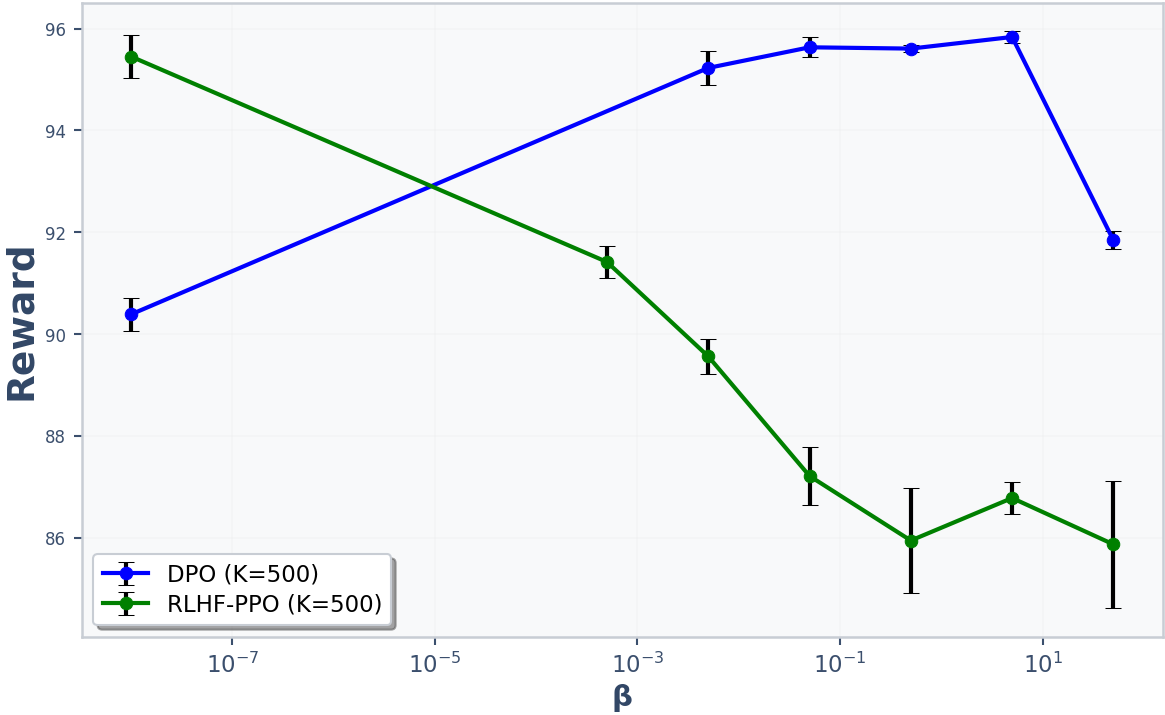

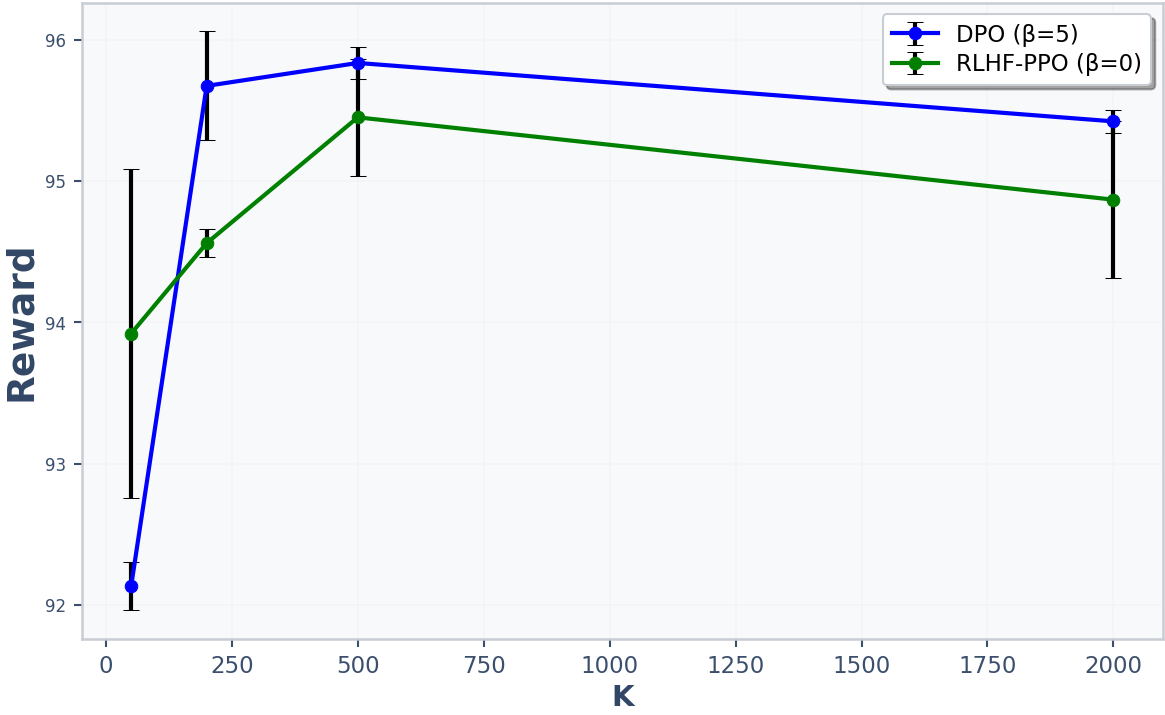

Saved plots: dpo_sweep_reward_vs_beta.pdf, dpo_sweep_reward_vs_K.pdf


In [77]:
# Visualize DPO parameter sweep results
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

dpo_results_file_50 = Path("dpo_parameter_sweep_results_K50.pkl")
dpo_results_file_200 = Path("dpo_parameter_sweep_results_K200.pkl")
dpo_results_file_500 = Path("dpo_parameter_sweep_results_K500.pkl")
dpo_results_file_2000 = Path("dpo_parameter_sweep_results_K2000.pkl")

ppo_results_file_50_200 = Path("rlhf_ppo_parameter_sweep_results_K50_200.pkl")
ppo_results_file_500_2000 = Path("rlhf_ppo_parameter_sweep_results_K500_2000.pkl")
ppo_results_file_beta_5e4 = Path("rlhf_ppo_parameter_sweep_results_K50_200_5e-4.pkl")



with dpo_results_file_50.open('rb') as f:
    sweep_results_50 = pickle.load(f)

with dpo_results_file_200.open('rb') as f:
    sweep_results_200 = pickle.load(f)

with dpo_results_file_500.open('rb') as f:
    sweep_results_500 = pickle.load(f)

with dpo_results_file_2000.open('rb') as f:
    sweep_results_2000 = pickle.load(f)

with ppo_results_file_50_200.open('rb') as f:
    sweep_results_50_200 = pickle.load(f)

with ppo_results_file_500_2000.open('rb') as f:
    sweep_results_500_2000 = pickle.load(f)

with ppo_results_file_beta_5e4.open('rb') as f:
    sweep_results_beta_5e4 = pickle.load(f)

dpo_result_files = [sweep_results_50, sweep_results_200, sweep_results_500, sweep_results_2000]
ppo_result_files = [sweep_results_50_200, sweep_results_500_2000, sweep_results_beta_5e4]
# Organize results by dataset size and beta
from collections import defaultdict
dpo_data = defaultdict(lambda: defaultdict(list))
ppo_data = defaultdict(lambda: defaultdict(list))
dataset_sizes = set()
dpo_betas = set()
ppo_betas = set()
for file in dpo_result_files:
    for r in file:
        k = r['dataset_size']
        b = r['beta']
        dataset_sizes.add(k)
        dpo_betas.add(b)
        # prefer recorded best_reward when available
        val = r.get('best_reward') if r.get('best_reward') is not None else r.get('history', {}).get('rewards', [None])[-1]
        dpo_data[k][b].append(val)

for file in ppo_result_files:
    for r in file:
        k = r['dataset_size']
        b = r['beta']
        dataset_sizes.add(k)
        ppo_betas.add(b)
        # prefer recorded best_reward when available
        val = r.get('best_reward') if r.get('best_reward') is not None else r.get('history', {}).get('rewards', [None])[-1]
        ppo_data[k][b].append(val)

dataset_sizes = sorted(dataset_sizes)
dpo_betas = sorted(dpo_betas)
ppo_betas = sorted(ppo_betas)

# Helper to safe-plot betas (avoid log(0) issues)
def beta_plot_x(b):
    return b if b != 0 else 1e-8



# Plot 1: For each K, vary beta on x-axis -> reward (mean across seeds)
plt.figure(figsize=(8, 5))

means = []
stds = []
k = 500
x = [beta_plot_x(b) for b in dpo_betas]
for b in dpo_betas:
    vals = np.array(dpo_data[k][b], dtype=np.float32) if len(dpo_data[k][b]) > 0 else np.array([np.nan], dtype=np.float32)
    means.append(np.nanmean(vals))
    stds.append(np.nanstd(vals))
# green mean line with blue error bars
plt.errorbar(x, means, yerr=stds, fmt='-o', color='blue', ecolor='black', capsize=4, label=f'DPO (K={k})')

means = []
stds = []
k = 500
x = [beta_plot_x(b) for b in ppo_betas]
for b in ppo_betas:
    vals = np.array(ppo_data[k][b], dtype=np.float32) if len(ppo_data[k][b]) > 0 else np.array([np.nan], dtype=np.float32)
    means.append(np.nanmean(vals))
    stds.append(np.nanstd(vals))
# green mean line with blue error bars
plt.errorbar(x, means, yerr=stds, fmt='-o', color='green', ecolor='black', capsize=4, label=f'RLHF-PPO (K={k})')

plt.xscale('log')
plt.xlabel('β', fontsize=14, fontweight='bold')
plt.tick_params(axis="x", labelsize=11)
plt.ylabel('Reward', fontsize=18, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dpo_sweep_reward_vs_beta.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: For each beta, vary K on x-axis -> reward (mean across seeds)
plt.figure(figsize=(8, 5))
beta = 5
means = []
stds = []
x = dataset_sizes
for k in dataset_sizes:
    vals = np.array(dpo_data[k][beta], dtype=np.float32) if len(dpo_data[k][beta]) > 0 else np.array([np.nan], dtype=np.float32)
    means.append(np.nanmean(vals))
    stds.append(np.nanstd(vals))
plt.errorbar(x, means, yerr=stds, fmt='-o', color='blue', ecolor='black', capsize=4, label=f'DPO (β={beta})')

beta = 0
means = []
stds = []
for k in dataset_sizes:
    vals = np.array(ppo_data[k][beta], dtype=np.float32) if len(ppo_data[k][beta]) > 0 else np.array([np.nan], dtype=np.float32)
    means.append(np.nanmean(vals))
    stds.append(np.nanstd(vals))
plt.errorbar(x, means, yerr=stds, fmt='-o', color='green', ecolor='black', capsize=4, label=f'RLHF-PPO (β={beta})')

plt.xlabel('K', fontsize=14, fontweight='bold')
plt.tick_params(axis="x", labelsize=11)
plt.ylabel('Reward', fontsize=18, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dpo_sweep_reward_vs_K.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved plots: dpo_sweep_reward_vs_beta.pdf, dpo_sweep_reward_vs_K.pdf")


### Visuals

In [ ]:
# Compare DPO vs RLHF PPO on the same beta sweep
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

comparison_dataset_size = 2000
comparison_output_path = f"dpo_vs_rlhf_ppo_beta_comparison_K{comparison_dataset_size}.png"


def load_sweep_results(result_path):
    if not result_path.exists():
        raise FileNotFoundError(f"Missing sweep results file: {result_path}")

    with result_path.open("rb") as file_handle:
        return pickle.load(file_handle)


def aggregate_best_reward_by_beta(results, dataset_size):
    grouped = defaultdict(list)

    for run in results:
        if run.get("dataset_size") != dataset_size:
            continue

        beta = run.get("beta")
        best_reward = run.get("best_reward")
        if best_reward is None:
            history = run.get("history", {})
            best_reward = history.get("best_reward")

        if beta is None or best_reward is None:
            continue

        grouped[beta].append(best_reward)

    betas = sorted(grouped)
    means = [float(np.mean(grouped[beta])) for beta in betas]
    stds = [float(np.std(grouped[beta])) for beta in betas]
    return betas, means, stds


dpo_results_file = Path("dpo_parameter_sweep_results.pkl")
rlhf_results_file = Path("rlhf_ppo_parameter_sweep_results.pkl")

dpo_results = load_sweep_results(dpo_results_file)
rlhf_results = load_sweep_results(rlhf_results_file)

dpo_betas, dpo_means, dpo_stds = aggregate_best_reward_by_beta(dpo_results, comparison_dataset_size)
rlhf_betas, rlhf_means, rlhf_stds = aggregate_best_reward_by_beta(rlhf_results, comparison_dataset_size)

plt.figure(figsize=(8, 5))
plt.errorbar(
    dpo_betas,
    dpo_means,
    yerr=dpo_stds,
    fmt='-o',
    color='green',
    ecolor='green',
    capsize=4,
    label='DPO',
)
plt.errorbar(
    rlhf_betas,
    rlhf_means,
    yerr=rlhf_stds,
    fmt='-o',
    color='blue',
    ecolor='blue',
    capsize=4,
    label='RLHF PPO',
)

plt.xlabel('beta')
plt.ylabel('Best reward across seeds')
plt.title(f'DPO vs RLHF PPO at K={comparison_dataset_size}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(comparison_output_path, dpi=200)
plt.show()

print(f"Saved comparison plot to {comparison_output_path}")


## PPO RLHF


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"


# ------------------------------------------------------------
# Reward Model
# ------------------------------------------------------------

class RewardModel(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, obs, acts):
        x = torch.cat([obs, acts], dim=-1)
        return self.net(x).squeeze(-1)


# ------------------------------------------------------------
# Convert trajectory → reward score
# ------------------------------------------------------------

def trajectory_reward(model, traj):
    obs = torch.tensor(
        [t[0] for t in traj],
        dtype=torch.float32,
        device=device
    )

    acts = torch.tensor(
        [t[1] for t in traj],
        dtype=torch.float32,
        device=device
    )

    if acts.dim() == 1:
        acts = acts.unsqueeze(-1)

    return model(obs, acts).sum()


# ------------------------------------------------------------
# Bradley-Terry preference loss (RLHF standard)
# ------------------------------------------------------------

def reward_model_loss(model, pref_traj, rej_traj):
    r_pref = trajectory_reward(model, pref_traj)
    r_rej  = trajectory_reward(model, rej_traj)

    logits = r_pref - r_rej

    return -F.logsigmoid(logits)


# ------------------------------------------------------------
# TRAIN REWARD MODEL
# ------------------------------------------------------------

def train_reward_model(reward_model, prefs, epochs=5, lr=1e-4):

    reward_model.to(device)
    optimizer = torch.optim.Adam(reward_model.parameters(), lr=lr)

    for epoch in range(epochs):

        total_loss = 0

        for pref, rej in prefs:

            loss = reward_model_loss(
                reward_model,
                pref,
                rej
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"[Reward Model] Epoch {epoch+1} | Loss: {total_loss/len(prefs):.4f}")

    return reward_model


In [20]:
env = gym.make("MountainCarContinuous-v0")

obs_dim = env.observation_space.shape[0]
act_dim = 1

with open("pref_dataset_2000.pkl", "rb") as f:
    pref_dataset = pickle.load(f)


# ------------------------------------------------------------
# 1. train reward model
# ------------------------------------------------------------

rm = RewardModel(obs_dim, act_dim)


In [46]:
# rm = train_reward_model(rm, pref_dataset, epochs=11, lr=1e-4)
rm.load_state_dict(torch.load("reward_model_50_11.pth"))

<All keys matched successfully>

In [33]:
with open("reward_model_500_11.pth", "wb") as f:
    torch.save(rm.state_dict(), f)


In [24]:
correct = 0
for pref, rej in pref_dataset:
    if trajectory_reward(rm, pref) > trajectory_reward(rm, rej):
        correct += 1
print(f"RM Accuracy: {correct / len(pref_dataset):.2f}")


RM Accuracy: 1.00


Evaluating SB3 vs RM | π1:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating SB3 vs RM | π2:   0%|          | 0/50 [00:00<?, ?it/s]

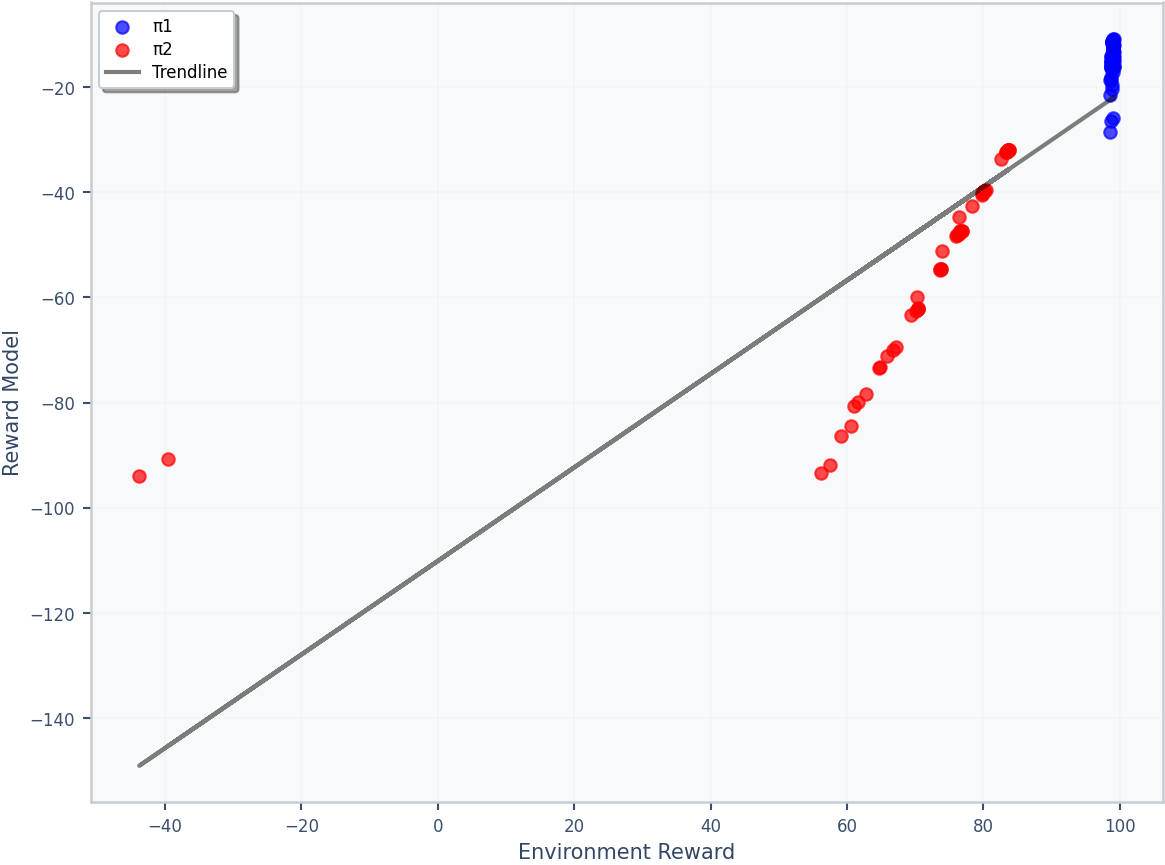

In [47]:
import numpy as np
import torch
import gymnasium as gym
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


def evaluate_sb3_policy_with_rm(models, reward_model=None, env_name="MountainCarContinuous-v0", episodes=50, render=False, device="cpu", plot=True):
    env = gym.make(env_name, render_mode="human" if render else None)

    real_rewards = []
    rm_rewards = []

    model_colors = ["blue", "red"]
    model_labels = ["π1", "π2"]

    if reward_model is not None and plot:
        plt.figure(figsize=(8, 6))

    for model_idx, model in enumerate(models):
        model_real_rewards = []
        model_rm_rewards = []
        pbar = tqdm(range(episodes), desc=f"Evaluating SB3 vs RM | {model_labels[model_idx]}")

        for _ in pbar:
            obs, _ = env.reset()
            done = False
            
            ep_real_reward = 0
            trajectory = []

            while not done:
                # Get action from the SB3 policy
                action, _states = model.predict(obs, deterministic=True)
                
                # Store the state-action pair for the RM
                trajectory.append((obs.copy(), action.copy()))

                obs, reward, done, trunc, _ = env.step(action)
                ep_real_reward += reward

                if trunc:
                    break

            real_rewards.append(ep_real_reward)
            model_real_rewards.append(ep_real_reward)

            # ------------------------------------------------------------
            # Calculate the total trajectory reward from the RM
            # ------------------------------------------------------------
            if reward_model is not None:
                obs_tensor = torch.tensor([t[0] for t in trajectory], dtype=torch.float32, device=device)
                acts_tensor = torch.tensor([t[1] for t in trajectory], dtype=torch.float32, device=device)
                
                if acts_tensor.ndim == 1:
                    acts_tensor = acts_tensor.unsqueeze(-1)
                
                with torch.no_grad():
                    # Use .sum() to evaluate the cumulative trajectory score
                    ep_rm_reward = reward_model(obs_tensor, acts_tensor).sum().item()
                    
                rm_rewards.append(ep_rm_reward)
                model_rm_rewards.append(ep_rm_reward)
                
                # Update progress bar to show both
                pbar.set_postfix(
                    real_avg=f"{np.mean(real_rewards):.1f}", 
                    rm_avg=f"{np.mean(rm_rewards):.1f}"
                )
            else:
                pbar.set_postfix(real_avg=f"{np.mean(real_rewards):.1f}")

        if reward_model is not None and plot:
            plt.scatter(
                model_real_rewards,
                model_rm_rewards,
                alpha=0.7,
                color=model_colors[model_idx],
                label=model_labels[model_idx],
            )

    env.close()

    # ------------------------------------------------------------
    # Plotting the Correlation
    # ------------------------------------------------------------
    if reward_model is not None and plot:
        # Add a trendline if there is variance in the real rewards
        if len(set(real_rewards)) > 1: 
            z = np.polyfit(real_rewards, rm_rewards, 1)
            p = np.poly1d(z)
            plt.plot(real_rewards, p(real_rewards), "k", alpha=0.5, label="Trendline")
            
        # plt.title("Diagnostics: Real Env Reward vs. Reward Model Prediction")
        plt.xlabel("Environment Reward")
        plt.ylabel("Reward Model")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig("reward_model_correlation_50.pdf")
        plt.show()

    return real_rewards, rm_rewards


real_scores, rm_scores = evaluate_sb3_policy_with_rm(
    models=[pi1, pi2], 
    reward_model=rm, 
    episodes=50, 
    device=device
)


## PPO Implementation

In [15]:
import gymnasium as gym
import torch
import numpy as np

class RLHFEnvWrapper(gym.Wrapper):
    def __init__(self, env, reward_model, ref_policy, beta=0.03, device="cpu"):
        super().__init__(env)
        self.reward_model = reward_model
        self.ref_policy = ref_policy
        self.beta = beta
        self.device = device
        self.current_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.current_obs = obs
        return obs, info

    def step(self, action):
        # 1. Execute step in the real environment
        next_obs, real_reward, done, truncated, info = self.env.step(action)
        
        # 2. Get the log probability from the reference policy for the KL penalty
        obs_t = torch.tensor(self.current_obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        act_t = torch.tensor(action, dtype=torch.float32, device=self.device).unsqueeze(0)
        
        with torch.no_grad():
            ref_dist = self.ref_policy.get_distribution(obs_t)
            ref_log_prob = ref_dist.log_prob(act_t).sum(dim=-1).item()
            
            # Note: We compute the active policy's log prob internally 
            # to approximate the token-level KL: log_pi - log_ref.
            # During native SB3 training, we anchor against the frozen ref log prob.
            # To simulate the step penalty safely:
            rm_score = self.reward_model(obs_t, act_t).item()

        # 3. Formulate the composite step reward 
        # (Using an engineered proxy for step-level anchor keeping)
        # To avoid the custom loop instability, we leverage SB3's native reward structures
        rlhf_reward = rm_score 
        
        self.current_obs = next_obs
        return next_obs, rlhf_reward, done, truncated, info


In [ ]:
from stable_baselines3 import PPO

from stable_baselines3.common.callbacks import BaseCallback
import torch
import copy

ref_model = copy.deepcopy(PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip"))
ref_policy = ref_model.policy


class KLObjectiveCallback(BaseCallback):
    def __init__(self, ref_policy, beta=0.02, verbose=0):
        super().__init__(verbose)
        self.ref_policy = ref_policy
        self.beta = beta

    def _on_rollout_end(self) -> None:
        """
        Triggered right before PPO updates its weights.
        We adjust the advantages in the rollout buffer by subtracting the KL penalty.
        """
        # Extract the data PPO just collected
        rollout_buffer = self.model.rollout_buffer
        
        # Convert buffer data to PyTorch tensors
        observations = torch.tensor(rollout_buffer.observations, dtype=torch.float32, device=self.model.device)
        actions = torch.tensor(rollout_buffer.actions, dtype=torch.float32, device=self.model.device)
        old_log_probs = torch.tensor(rollout_buffer.log_probs, dtype=torch.float32, device=self.model.device)

        # Reshape observations if necessary (removes the step dimension if flattened)
        if observations.ndim == 4: # handling vector envs
            observations = observations.squeeze(1)
            actions = actions.squeeze(1)

        with torch.no_grad():
            # Get reference policy distributions
            ref_features = self.ref_policy.extract_features(observations)
            ref_dist = self.ref_policy.get_distribution(observations)
            ref_log_probs = ref_dist.log_prob(actions)

            # KL = log pi_old - log pi_ref
            kl_divergence = old_log_probs - ref_log_probs
            
        # Reshape KL back to match the buffer shape
        kl_penalty = (self.beta * kl_divergence).cpu().numpy().reshape(rollout_buffer.advantages.shape)
        
        # Apply the leash! Subtract the penalty directly from the advantages PPO uses to learn
        rollout_buffer.advantages -= kl_penalty
        
    def _on_step(self) -> bool:
        return True
    
reward_model = RewardModel(obs_dim, act_dim)
reward_model.load_state_dict(torch.load("reward_model_2000_11.pth"))

# 1. Wrap your environment
rlhf_env = RLHFEnvWrapper(
    env=gym.make("MountainCarContinuous-v0"),
    reward_model=rm,
    ref_policy=ref_policy,
    beta=0.02,
    device=device
)

# 2. Add an evaluation env that measures true task reward
goal_reward = 95.0
eval_env = Monitor(gym.make("MountainCarContinuous-v0"))
stop_on_goal = StopTrainingOnRewardThreshold(reward_threshold=goal_reward, verbose=1)
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path="./rlhf_ppo_best",
    log_path="./rlhf_ppo_logs",
    callback_on_new_best=stop_on_goal,
    eval_freq=250,
    n_eval_episodes=8,
    deterministic=True,
    verbose=1,
)

# 3. Instantiate a native PPO agent using standard stable hyperparameters
rlhf_ppo_sb3_model = PPO(
    "MlpPolicy",
    rlhf_env,
    learning_rate=3e-4,     # Native PPO default
    n_steps=512,            # Shorter rollout window fits Mountain Car well
    batch_size=64,
    n_epochs=10,            # Robust internal optimization epochs
    gamma=0.99,
    verbose=1,
    device=device
)

# 4. Seed with reference
rlhf_ppo_sb3_model.policy.load_state_dict(ref_policy.state_dict())

# 5. Train with kl and early stop
set_seed(4)
kl_callback = KLObjectiveCallback(ref_policy=ref_policy, beta=0.0)
rlhf_ppo_sb3_model.learn(total_timesteps=20000, callback=[kl_callback, eval_callback])

# Best-ever policy is stored automatically in ./rlhf_ppo_best/best_model.zip


In [ ]:
rlhf_ppo_sb3_model.save("rlhf_ppo_sb3_mountaincar.zip")


Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 92.16 ± 2.23


Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 98.90 ± 0.14


Evaluating SB3 Policy:   0%|          | 0/50 [00:00<?, ?it/s]

Average Reward over 50 episodes: 88.56 ± 2.59


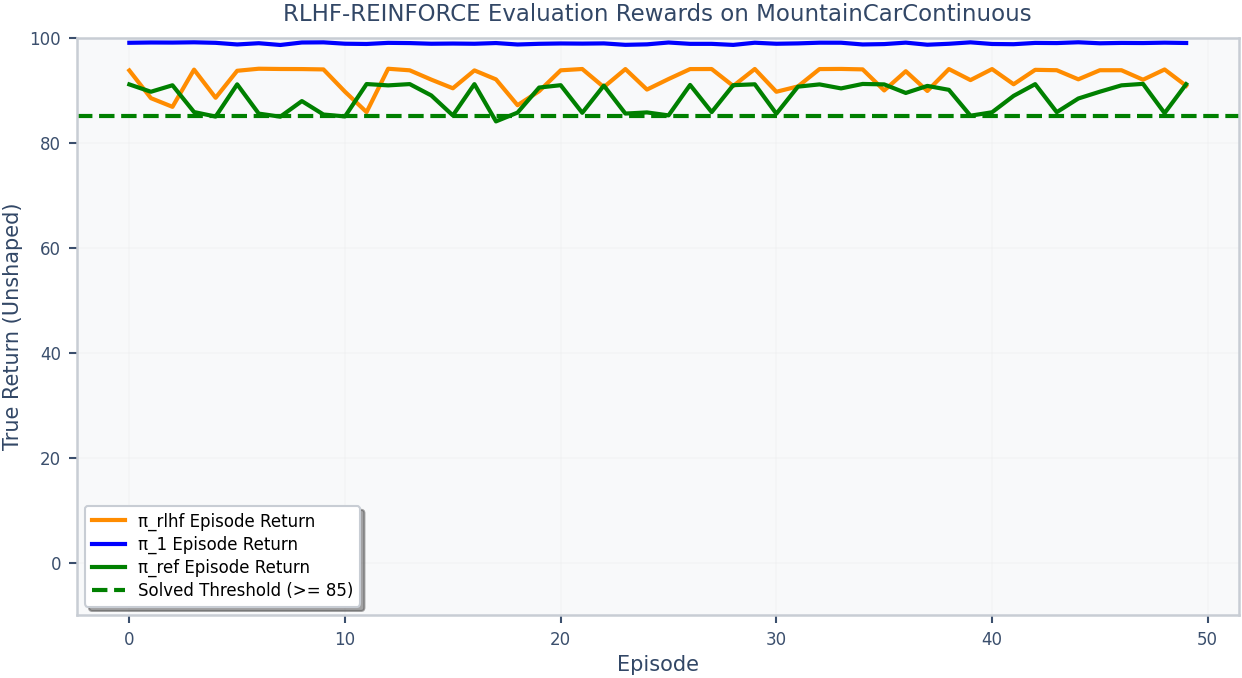

In [27]:
pi_rlhf= PPO.load("rlhf_ppo_sb3_mountaincar.zip")
pi_rlhf = PPO.load("./rlhf_ppo_best/best_model.zip")
pi1 = PPO.load("ppo_mountaincar_continuous_pi1_save.zip")
pi_ref = PPO.load("ppo_mountaincar_continuous_pi_ref_save.zip")


mean_reward_rlhf, std_reward_rlhf, episode_rewards_rlhf = evaluate_sb3_policy(pi_rlhf, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward_rlhf:.2f} ± {std_reward_rlhf:.2f}")

mean_reward1, std_reward1, episode_rewards1 = evaluate_sb3_policy(pi1, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward1:.2f} ± {std_reward1:.2f}")

mean_reward_ref, std_reward_ref, episode_rewards_ref = evaluate_sb3_policy(pi_ref, episodes=50)
print(f"Average Reward over 50 episodes: {mean_reward_ref:.2f} ± {std_reward_ref:.2f}")

# 3. Plot the performance results
plt.figure(figsize=(10, 5))

plt.plot(episode_rewards_rlhf, label="π_rlhf Episode Return", color="darkorange", linewidth=2)
plt.plot(episode_rewards1, label="π_1 Episode Return", color="blue", linewidth=2)
plt.plot(episode_rewards_ref, label="π_ref Episode Return", color="green", linewidth=2)

plt.axhline(y=85.0, color="green", linestyle="--", label="Solved Threshold (>= 85)")
plt.title("RLHF-REINFORCE Evaluation Rewards on MountainCarContinuous")
plt.xlabel("Episode")
plt.ylabel("True Return (Unshaped)")
plt.ylim(-10, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [52]:
pi = PPO.load("rlhf_ppo_sb3_mountaincar.zip")
pi = PPO.load("./rlhf_ppo_best/best_model.zip")
pi = PPO.load("rlhf_ppo_parameter_sweep_best_models/rlhf_k2000_beta0p0_seed2.zip")
video_file = record_sb3_policy(pi, filename="mountain_car_rlhf_ppo_sb3.mp4")
Video(video_file)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved successfully to mountain_car_rlhf_ppo_sb3.mp4!
Total reward: 93.49294207397098


### PPO Parameter sweep

In [9]:
# RLHF PPO parameter sweep
import copy
from pathlib import Path

rlhf_sweep_results_path = "rlhf_ppo_parameter_sweep_results_K50.pkl"
rlhf_sweep_best_models_dir = Path("rlhf_ppo_parameter_sweep_best_models")
rlhf_sweep_best_models_dir.mkdir(exist_ok=True)


def beta_to_tag(beta):
    return str(beta).replace("-", "m").replace("+", "p").replace(".", "p")


def evaluate_rlhf_policy(model, reward_model, ref_policy, beta, episodes=6, env_name="MountainCarContinuous-v0"):
    env = gym.make(env_name)
    true_rewards = []
    objective_rewards = []

    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        ep_true_reward = 0.0
        ep_rm_reward = 0.0
        ep_kl_proxy = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)

            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            act_tensor = torch.tensor(action, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                current_dist = model.policy.get_distribution(obs_tensor)
                ref_dist = ref_policy.get_distribution(obs_tensor)
                current_log_prob = current_dist.log_prob(act_tensor).sum(dim=-1)
                ref_log_prob = ref_dist.log_prob(act_tensor).sum(dim=-1)
                rm_score = reward_model(obs_tensor, act_tensor).item()

            obs, reward, terminated, truncated, _ = env.step(action)
            ep_true_reward += reward
            ep_rm_reward += rm_score
            ep_kl_proxy += (current_log_prob - ref_log_prob).item()
            done = terminated or truncated

        objective_reward = ep_rm_reward - beta * ep_kl_proxy
        true_rewards.append(ep_true_reward)
        objective_rewards.append(objective_reward)

    env.close()

    return {
        "true_rewards": true_rewards,
        "objective_rewards": objective_rewards,
        "mean_true_reward": float(np.mean(true_rewards)),
        "mean_objective_reward": float(np.mean(objective_rewards)),
        "loss_proxy": float(-np.mean(objective_rewards)),
    }


def train_rlhf_ppo_with_history(
    reward_model,
    ref_policy,
    beta,
    total_timesteps=2500,
    chunk_timesteps=500,
    eval_episodes=6,
    env_name="MountainCarContinuous-v0",
):
    rlhf_env = RLHFEnvWrapper(
        env=gym.make(env_name),
        reward_model=reward_model,
        ref_policy=ref_policy,
        beta=beta,
        device=device,
    )

    train_model = PPO(
        "MlpPolicy",
        rlhf_env,
        learning_rate=3e-4,
        n_steps=512,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        verbose=0,
        device=device,
    )
    train_model.policy.load_state_dict(ref_policy.state_dict())

    kl_callback = KLObjectiveCallback(ref_policy=ref_policy, beta=beta)

    rewards = []
    losses = []
    best_reward = -float("inf")
    best_epoch = -1
    best_policy = copy.deepcopy(train_model.policy)

    completed_steps = 0
    epoch = 0
    while completed_steps < total_timesteps:
        step_chunk = min(chunk_timesteps, total_timesteps - completed_steps)
        train_model.learn(
            total_timesteps=step_chunk,
            callback=[kl_callback],
            reset_num_timesteps=False,
            progress_bar=False,
        )

        metrics = evaluate_rlhf_policy(
            train_model,
            reward_model=reward_model,
            ref_policy=ref_policy,
            beta=beta,
            episodes=eval_episodes,
            env_name=env_name,
        )

        epoch += 1
        rewards.append(metrics["mean_true_reward"])
        losses.append(metrics["loss_proxy"])

        if metrics["mean_true_reward"] > best_reward:
            best_reward = metrics["mean_true_reward"]
            best_epoch = epoch
            best_policy = copy.deepcopy(train_model.policy)

        completed_steps += step_chunk

    rlhf_env.close()

    history = {
        "rewards": rewards,
        "losses": losses,
        "best_reward": best_reward,
        "best_epoch": best_epoch,
    }

    return best_policy, history


def run_rlhf_ppo_parameter_sweep(
    dataset_sizes=(500, 2000),
    betas=(0.0, 5e-3, 5e-2, 5e-1, 5.0, 50.0),
    seeds=(0, 1, 2),
    total_timesteps=25000,
    chunk_timesteps=1000,
    reward_model_epochs=11,
    reward_model_lr=1e-4,
    eval_episodes=6,
    save_path=rlhf_sweep_results_path,
    env_name="MountainCarContinuous-v0",
):
    base_model = PPO.load(base_model_path)
    obs_dim = gym.make(env_name).observation_space.shape[0]
    act_dim = 1
    sweep_results = []

    for dataset_size in dataset_sizes:
        rm_path = Path(f"reward_model_{dataset_size}_11.pth")
        if not rm_path.exists():
            raise FileNotFoundError(f"Missing reward model: {rm_path}")

        reward_model = RewardModel(obs_dim, act_dim)
        reward_model.load_state_dict(torch.load(rm_path))

        for beta in betas:
            for seed in seeds:
                set_seed(seed)

                ref_model = copy.deepcopy(base_model)
                ref_policy = ref_model.policy
                ref_policy.eval()
                for param in ref_policy.parameters():
                    param.requires_grad = False

                best_policy, history = train_rlhf_ppo_with_history(
                    reward_model=reward_model,
                    ref_policy=ref_policy,
                    beta=beta,
                    total_timesteps=total_timesteps,
                    chunk_timesteps=chunk_timesteps,
                    eval_episodes=eval_episodes,
                    env_name=env_name,
                )

                beta_tag = beta_to_tag(beta)
                best_model = copy.deepcopy(base_model)
                best_model.policy.load_state_dict(best_policy.state_dict())
                best_model_path = rlhf_sweep_best_models_dir / f"rlhf_k{dataset_size}_beta{beta_tag}_seed{seed}.zip"
                best_model.save(str(best_model_path))

                run_result = {
                    "dataset_size": dataset_size,
                    "beta": beta,
                    "seed": seed,
                    "total_timesteps": total_timesteps,
                    "chunk_timesteps": chunk_timesteps,
                    "reward_model_epochs": reward_model_epochs,
                    "reward_model_lr": reward_model_lr,
                    "eval_episodes": eval_episodes,
                    "history": history,
                    "best_reward": history["best_reward"],
                    "best_epoch": history["best_epoch"],
                    "best_model_path": str(best_model_path),
                }
                sweep_results.append(run_result)

                print(
                    f"[rlhf sweep] K={dataset_size} beta={beta:g} seed={seed} | "
                    f"best_reward={history['best_reward']:.2f} at checkpoint {history['best_epoch']}"
                )

    with open(save_path, "wb") as file_handle:
        pickle.dump(sweep_results, file_handle)

    print(f"Saved {len(sweep_results)} RLHF PPO sweep runs to {save_path}")
    return sweep_results

# Uncomment to run the sweep when you are ready.
# rlhf_ppo_sweep_results = run_rlhf_ppo_parameter_sweep()


### PPO Parameter sweep

In [ ]:
rlhf_ppo_sweep_results = run_rlhf_ppo_parameter_sweep()


### Pretty plots

--- Evaluating K=500 ---
ppo_mountaincar_continuous_pi1_save.zip: mean=98.84, seed_rewards=[98.91558074951172, 98.85903930664062, 98.89401245117188, 98.61800384521484, 98.89002990722656]
ppo_mountaincar_continuous_pi2_save.zip: mean=53.09, seed_rewards=[69.79270935058594, 71.7444839477539, 80.22235107421875, 83.70500946044922, -40.03706741333008]
ppo_mountaincar_continuous_pi_ref_save.zip: mean=89.31, seed_rewards=[88.88838195800781, 90.06148529052734, 90.89960479736328, 91.18344116210938, 85.50092315673828]
dpo_goat.zip: mean=94.65, seed_rewards=[92.43736267089844, 95.31234741210938, 95.7208023071289, 93.53115844726562, 96.27074432373047]
rlhf_k2000_beta0p0_seed2.zip: mean=94.07, seed_rewards=[95.7628402709961, 96.58515930175781, 90.78742218017578, 95.30355072021484, 91.927490234375]


/tmp/ipykernel_12693/1552905644.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


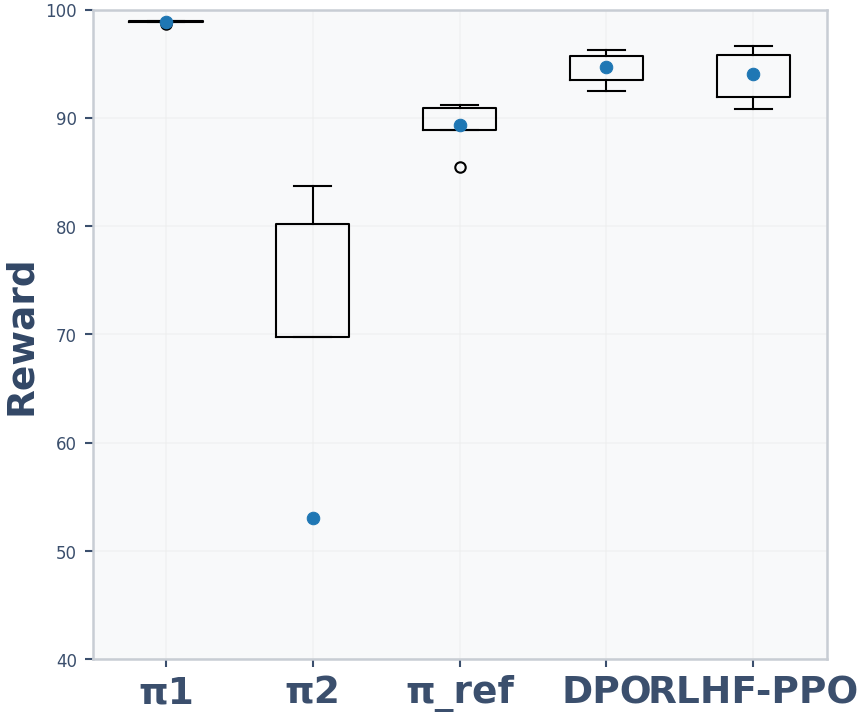

In [ ]:
def evaluate_sb3_policy_over_seeds(model, seeds, env_name="MountainCarContinuous-v0"):
    seed_returns = []

    for seed in seeds:
        env = gym.make(env_name)
        obs, _ = env.reset(seed=seed)
        env.action_space.seed(seed)

        done = False
        total_reward = 0.0

        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

        env.close()
        seed_returns.append(total_reward)

    seed_returns = np.asarray(seed_returns, dtype=np.float32)
    return seed_returns.tolist()


def plot_model_comparison_across_datasets(
    dataset_models, seeds, env_name="MountainCarContinuous-v0"
):
    """Plots a side-by-side boxplot comparison matching the target style.

    Args:
        dataset_models (dict): A dictionary where keys are dataset names and
          values are dicts containing 'files' and 'display_names'.
        seeds (list): List of seeds to evaluate over.
        env_name (str): Gym environment ID.
    """
    num_datasets = len(dataset_models)

    # Dynamically adjust figure size based on the number of subplots
    fig, axes = plt.subplots(
        1, num_datasets, figsize=(6 * num_datasets, 5), sharey=True
    )

    if num_datasets == 1:
        axes = [axes]

    # Unpack the dataset name and its respective inner configuration dictionary
    for ax, (dataset_name, config) in zip(axes, dataset_models.items()):
        all_rewards = []
        labels = config["display_names"]
        file_paths = config["files"]

        print(f"--- Evaluating {dataset_name} ---")
        for model_zip_path in file_paths:
            model_path = Path(model_zip_path)
            if not model_path.exists():
                raise FileNotFoundError(
                    f"Model file not found: {model_zip_path}"
                )

            model = PPO.load(str(model_path))
            seed_rewards = evaluate_sb3_policy_over_seeds(
                model, seeds=seeds, env_name=env_name
            )

            all_rewards.append(seed_rewards)

            print(
                f"{model_path.name}: mean={np.mean(seed_rewards):.2f}, seed_rewards={seed_rewards}"
            )

        # Create the Boxplot with hidden median and blue circle mean markers
        box = ax.boxplot(
            all_rewards,
            labels=labels,
            showmeans=True,
            meanprops={
                "marker": "o",                 # Circle marker
                "markerfacecolor": "tab:blue",  # Blue fill
                "markeredgecolor": "tab:blue",  # Blue border
            },
            medianprops={
                "linewidth": 0
            },  # Hides the orange median line
            flierprops={"marker": "o", "color": "black", "markersize": 5},
        )

        # Style elements matching the target image geometry
        # ax.set_title(dataset_name, fontsize=16, fontweight="bold", pad=15)
        ax.grid(True, linestyle="-", alpha=0.5)
        ax.tick_params(axis="x", labelsize=11)

        # Make labels bold
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")

    axes[0].set_ylabel("Reward", fontsize=18, fontweight="bold")
    axes[0].set_ylim(40, 100)

    plt.tight_layout()
    plt.savefig("model_comparison_across_datasets.png", dpi=300)
    plt.show()


# --- CONFIGURATION & EXECUTION ---

dataset_experiments = {
    "K=500": {
        "files": [
            "ppo_mountaincar_continuous_pi1_save.zip",
            "ppo_mountaincar_continuous_pi2_save.zip",
            "ppo_mountaincar_continuous_pi_ref_save.zip",
            "models/dpo_goat.zip",
            "rlhf_ppo_parameter_sweep_best_models/rlhf_k2000_beta0p0_seed2.zip",
        ],
        "display_names": ["π1", "π2", "π_ref", "DPO", "RLHF-PPO"],
    },
}

seeds = [0, 1, 2, 3, 4]

plot_model_comparison_across_datasets(dataset_experiments, seeds)
